In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read files
df = pd.read_csv("C:\\Users\\arahm\\OneDrive\\Desktop\\Mnist.csv")
print(df.shape)
df.head()


(70000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


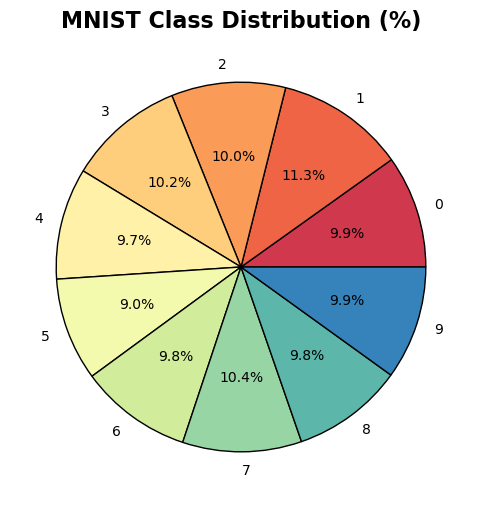

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
df['label'].value_counts().sort_index().plot.pie(
    autopct='%1.1f%%',
    colors=sns.color_palette('Spectral', 10),   # 10 classes (0–9)
    wedgeprops={'edgecolor': 'black'}
)

plt.title('MNIST Class Distribution (%)', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.show()


In [3]:
df = df.sample(frac=1, random_state=0).reset_index(drop=True) #after shuffling sort the index again
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


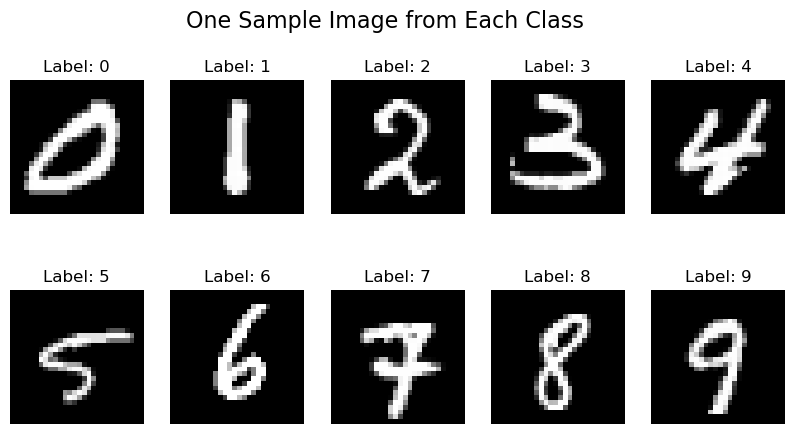

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, label in enumerate(sorted(df['label'].unique())):
    sample = df[df['label'] == label].iloc[0, 1:].values.reshape(28, 28)
    axes[i // 5, i % 5].imshow(sample, cmap='gray')
    axes[i // 5, i % 5].set_title(f'Label: {label}')
    axes[i // 5, i % 5].axis('off')
plt.suptitle("One Sample Image from Each Class", fontsize=16)
plt.show()


In [5]:
from sklearn.model_selection import train_test_split
X = df.drop("label", axis=1)
y = df["label"]
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("Validation:", X_val.shape, y_val.shape)

Train: (42000, 784) (42000,)
Test: (14000, 784) (14000,)
Validation: (14000, 784) (14000,)
